In [6]:
import math
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

TITLE_SIZE = 16
LABEL_SIZE = 14
TICK_SIZE = 12

# =========================
# PADEN
# =========================
excel_path = Path(r"C:\Users\verav\Desktop\Studie\Afstuderen\Output\Decay_calibration_outputs_V2\damping_summary_all_dofs\damping_summary_all_dofs.xlsx")

output_dir = excel_path.parent          # figuren komen naast de data
output_dir.mkdir(parents=True, exist_ok=True)

# =========================
# DOFS
# =========================
dofs = ["heave", "pitch", "roll"]
rot_dofs = ("pitch", "roll")            # rotatie-DOFs -> in graden ipv radialen

# rad -> deg conversie voor de dempingscoefficienten:
#   M = B_lin * omega + B_quad * omega|omega|
#   omega_rad = (pi/180) * omega_deg
#   => B_lin_deg  = B_lin_rad  * (pi/180)
#      B_quad_deg = B_quad_rad * (pi/180)^2
DEG = math.pi / 180.0

# =========================
# CONSTRUCTIES
# =========================
constructions = ["fixedwith", "fixedwithout", "spring"]

name_map = {
    "fixedwith": "Fixed with deck",
    "fixedwithout": "Fixed without deck",
    "spring": "Spring with deck",
}

# Alle constructies dezelfde kleur:
construction_color = "#1f77b4"
color_map = {c: construction_color for c in constructions}


In [7]:
# =========================
# DATA INLEZEN
# =========================
# Beschikbare sheets in dit bestand:
#   individual_results_all_dofs : per decay-experiment de gekalibreerde demping
#   mean_per_construction_dof   : gemiddelde per constructie + DOF
#   overall_mean_per_dof        : gemiddelde over alle constructies per DOF
ind  = pd.read_excel(excel_path, sheet_name="individual_results_all_dofs")
mean = pd.read_excel(excel_path, sheet_name="mean_per_construction_dof")
glob = pd.read_excel(excel_path, sheet_name="overall_mean_per_dof")

for df in (ind, mean, glob):
    df.columns = [c.strip() for c in df.columns]
    df["dof"] = df["dof"].str.lower()


def to_unit(dof, lin, quad):
    """Zet lineaire/kwadratische demping om naar graden voor de rotatie-DOFs."""
    if dof in rot_dofs:
        return lin * DEG, quad * DEG**2
    return lin, quad


def damping_units(dof):
    """Aslabels (graden voor pitch/roll, m/s voor heave)."""
    if dof in rot_dofs:
        return r"$\mathrm{kNm/(deg/s)}$", r"$\mathrm{kNm/(deg/s)^2}$"
    return r"$\mathrm{kN/(m/s)}$", r"$\mathrm{kN/(m/s)^2}$"


In [8]:
# =========================
# SAMENVATTING: gemiddelde demping per constructie + DOF
# =========================
summary_table = mean[[
    "dof",
    "construction",
    "n",
    "mean_viscous_linear_damping",
    "mean_viscous_quadratic_damping",
    "radiation_damping",
    "mean_total_linear_damping",
    "mean_total_quadratic_damping",
]].copy()

summary_table


,dof,construction,n,mean_viscous_linear_damping,mean_viscous_quadratic_damping,radiation_damping,mean_total_linear_damping,mean_total_quadratic_damping
0,heave,spring,4,4.562500,2.750000,2.23,6.792500,2.750000
1,heave,fixedwith,4,4.437500,2.937500,3.05,7.487500,2.937500
2,heave,fixedwithout,4,0.812500,1.375000,4.00,4.812500,1.375000
3,pitch,spring,3,330.000000,77.777778,88.35,418.350000,77.777778
4,pitch,fixedwith,3,277.777778,527.777778,142.78,420.557778,527.777778
5,pitch,fixedwithout,4,164.166667,1145.833333,176.24,340.406667,1145.833333
6,roll,spring,4,298.333333,112.500000,82.50,380.833333,112.500000
7,roll,fixedwith,3,247.777778,583.333333,142.78,390.557778,583.333333
8,roll,fixedwithout,4,129.166667,287.500000,176.24,305.406667,287.500000


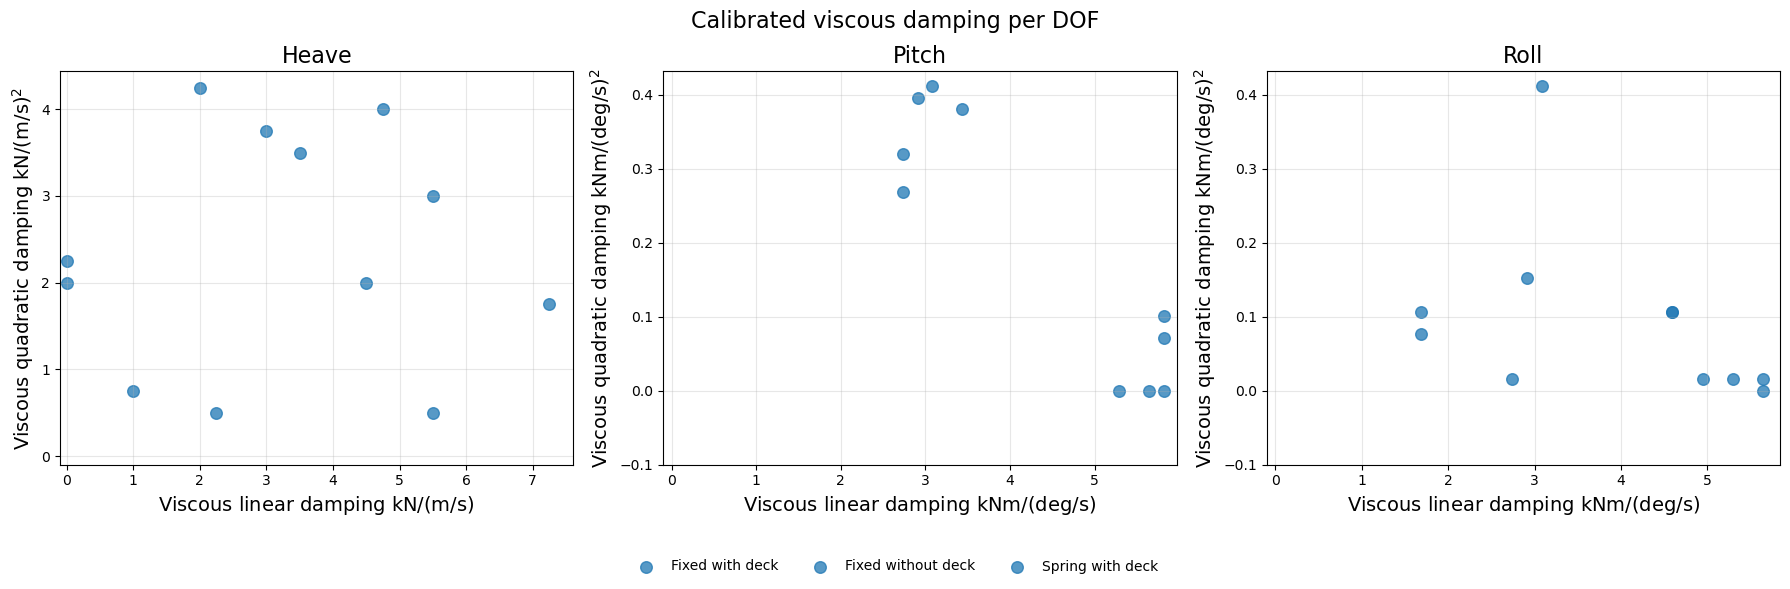

Plot opgeslagen als: C:\Users\verav\Desktop\Studie\Afstuderen\Output\Decay_calibration_outputs_V2\damping_summary_all_dofs\damping_viscous_per_dof.png


In [13]:
# =========================
# PLOT 1: viskeuze demping per DOF (lin vs quad)
#   o  = individuele decay-experimenten
#   x  = gemiddelde per constructie
# =========================
output_path = output_dir / "damping_viscous_per_dof.png"

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=False, sharey=False)

for ax, dof in zip(axes, dofs):
    di = ind[ind["dof"] == dof]
    mi = mean[mean["dof"] == dof]

    for construction in constructions:
        color = color_map[construction]

        sub = di[di["construction"] == construction]
        if not sub.empty:
            x, y = to_unit(dof, sub["linear_damping"], sub["quadratic_damping"])
            ax.scatter(x, y, marker="o", s=70, color=color, alpha=0.75,
                       label=name_map[construction])

        sm = mi[mi["construction"] == construction]
        if not sm.empty:
            row = sm.iloc[0]
            x, y = to_unit(dof, row["mean_viscous_linear_damping"],
                                row["mean_viscous_quadratic_damping"])
            # ax.scatter(x, y, marker="x", s=160, linewidths=3, color=color)

    lin_unit, quad_unit = damping_units(dof)
    ax.set_title(dof.capitalize(), fontsize=TITLE_SIZE)
    ax.set_xlabel(f"Viscous linear damping {lin_unit}", fontsize=LABEL_SIZE)
    ax.set_ylabel(f"Viscous quadratic damping {quad_unit}", fontsize=LABEL_SIZE)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(left=-0.1)
    ax.set_ylim(bottom=-0.10)

# legenda (gedupliceerd over de subplots wegfilteren)
handles, labels = [], []
for ax in axes:
    h, l = ax.get_legend_handles_labels()
    handles.extend(h); labels.extend(l)
unique = dict(zip(labels, handles))
fig.legend(unique.values(), unique.keys(), loc="lower center", ncol=3,
           frameon=False, bbox_to_anchor=(0.5, -0.03))

fig.suptitle("Calibrated viscous damping per DOF", fontsize=16, y=0.93)
fig.tight_layout(rect=[0, 0.06, 1, 0.96])
fig.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Plot opgeslagen als: {output_path}")


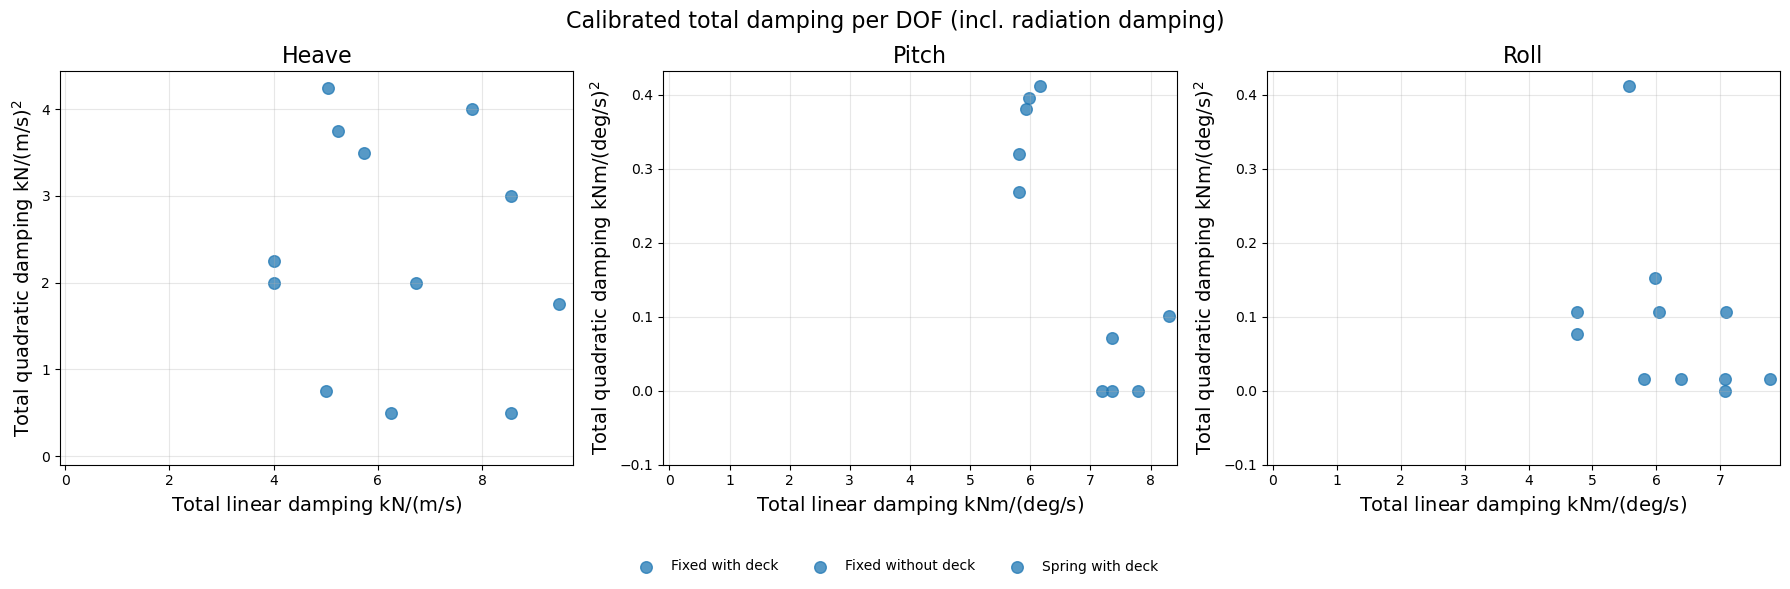

Plot opgeslagen als: C:\Users\verav\Desktop\Studie\Afstuderen\Output\Decay_calibration_outputs_V2\damping_summary_all_dofs\damping_total_per_dof.png


In [18]:
# =========================
# PLOT 2: totale demping per DOF (incl. radiation damping)
# =========================
output_path = output_dir / "damping_total_per_dof.png"

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=False, sharey=False)

for ax, dof in zip(axes, dofs):
    di = ind[ind["dof"] == dof]
    mi = mean[mean["dof"] == dof]
    gi = glob[glob["dof"] == dof]

    for construction in constructions:
        color = color_map[construction]

        sub = di[di["construction"] == construction]
        if not sub.empty:
            x, y = to_unit(dof, sub["total_linear_damping"], sub["total_quadratic_damping"])
            ax.scatter(x, y, marker="o", s=70, color=color, alpha=0.75,
                       label=name_map[construction])

        sm = mi[mi["construction"] == construction]
        if not sm.empty:
            row = sm.iloc[0]
            x, y = to_unit(dof, row["mean_total_linear_damping"],
                                row["mean_total_quadratic_damping"])
            # ax.scatter(x, y, marker="x", s=160, linewidths=3, color=color)

    # overall gemiddelde over de constructies
    if not gi.empty:
        row = gi.iloc[0]
        x, y = to_unit(dof, row["total_linear_damping"], row["total_quadratic_damping"])
        # ax.scatter(x, y, marker="x", s=200, color="black", edgecolor="white",
                #    linewidth=3.0, label="Overall mean", zorder=3)

    lin_unit, quad_unit = damping_units(dof)
    ax.set_title(dof.capitalize(), fontsize=TITLE_SIZE)
    ax.set_xlabel(f"Total linear damping {lin_unit}", fontsize=LABEL_SIZE)
    ax.set_ylabel(f"Total quadratic damping {quad_unit}", fontsize=LABEL_SIZE)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(left=-0.1)
    ax.set_ylim(bottom=-0.10)

handles, labels = [], []
for ax in axes:
    h, l = ax.get_legend_handles_labels()
    handles.extend(h); labels.extend(l)
unique = dict(zip(labels, handles))
fig.legend(unique.values(), unique.keys(), loc="lower center", ncol=4,
           frameon=False, bbox_to_anchor=(0.5, -0.03))

fig.suptitle("Calibrated total damping per DOF (incl. radiation damping)", fontsize=16, y=0.93)
fig.tight_layout(rect=[0, 0.06, 1, 0.96])
fig.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Plot opgeslagen als: {output_path}")


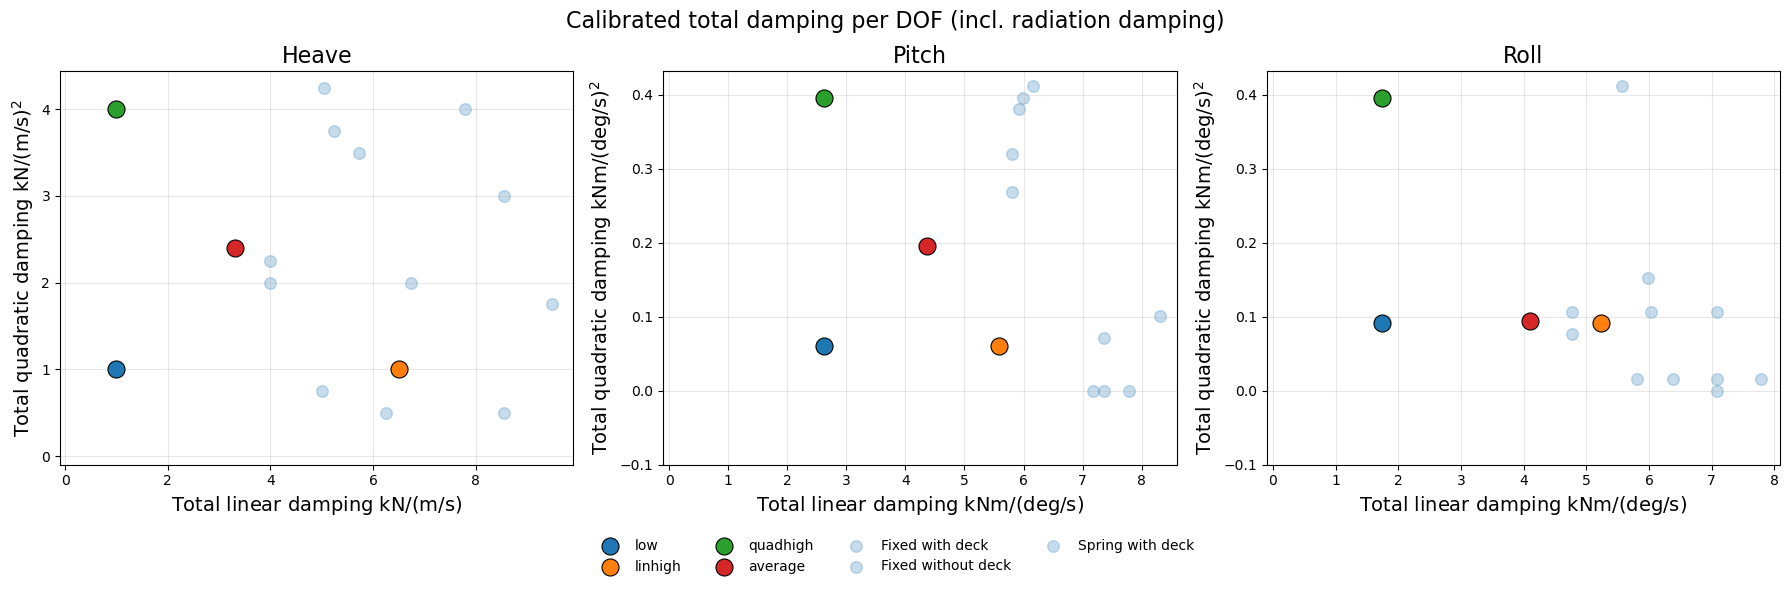

Plot opgeslagen als: C:\Users\verav\Desktop\Studie\Afstuderen\Output\Decay_calibration_outputs_V2\damping_summary_all_dofs\damping_total_per_dof.png


In [21]:
# =========================
# PLOT 2: totale demping per DOF (incl. radiation damping)
# =========================
output_path = output_dir / "damping_total_per_dof.png"



# fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=False, sharey=False)


cases = {
    "heave": {"low": (1.0, 1.0),  "linhigh": (6.5, 1.0),  "quadhigh": (1.0, 4.0),   "average": (3.3, 2.4)},
    "pitch": {"low": (150, 200),  "linhigh": (320, 200),  "quadhigh": (150, 1300),  "average": (250, 640)},
    "roll":  {"low": (100, 300),  "linhigh": (300, 300),  "quadhigh": (100, 1300),  "average": (235, 310)},
}

case_color = {
    "low":      "#1f77b4",   # blauw
    "linhigh":  "#ff7f0e",   # oranje
    "quadhigh": "#2ca02c",   # groen
    "average":  "#d62728",   # rood
}

data_color = "#9ecae1"       # licht (data op de achtergrond)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=False, sharey=False)

for ax, dof in zip(axes, dofs):
    di = ind[ind["dof"] == dof]

    # data licht op de achtergrond
    
    # cases er bovenop
    for case, (lin, quad) in cases[dof].items():
        cx, cy = to_unit(dof, lin, quad)
        ax.scatter(cx, cy, marker="o", s=150, color=case_color[case],
                   edgecolor="black", linewidth=0.8, label=case, zorder=3)

for ax, dof in zip(axes, dofs):
    di = ind[ind["dof"] == dof]
    mi = mean[mean["dof"] == dof]
    gi = glob[glob["dof"] == dof]

    for construction in constructions:
        color = color_map[construction]

        sub = di[di["construction"] == construction]
        if not sub.empty:
            x, y = to_unit(dof, sub["total_linear_damping"], sub["total_quadratic_damping"])
            ax.scatter(x, y, marker="o", s=70, color=color, alpha=0.25,
                       label=name_map[construction])

        sm = mi[mi["construction"] == construction]
        if not sm.empty:
            row = sm.iloc[0]
            x, y = to_unit(dof, row["mean_total_linear_damping"],
                                row["mean_total_quadratic_damping"])
            # ax.scatter(x, y, marker="x", s=160, linewidths=3, color=color)

    # overall gemiddelde over de constructies
    if not gi.empty:
        row = gi.iloc[0]
        x, y = to_unit(dof, row["total_linear_damping"], row["total_quadratic_damping"])
        # ax.scatter(x, y, marker="x", s=200, color="black", edgecolor="white",
                #    linewidth=3.0, label="Overall mean", zorder=3)

    lin_unit, quad_unit = damping_units(dof)
    ax.set_title(dof.capitalize(), fontsize=TITLE_SIZE)
    ax.set_xlabel(f"Total linear damping {lin_unit}", fontsize=LABEL_SIZE)
    ax.set_ylabel(f"Total quadratic damping {quad_unit}", fontsize=LABEL_SIZE)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(left=-0.1)
    ax.set_ylim(bottom=-0.10)

handles, labels = [], []
for ax in axes:
    h, l = ax.get_legend_handles_labels()
    handles.extend(h); labels.extend(l)
unique = dict(zip(labels, handles))
fig.legend(unique.values(), unique.keys(), loc="lower center", ncol=4,
           frameon=False, bbox_to_anchor=(0.5, -0.03))

fig.suptitle("Calibrated total damping per DOF (incl. radiation damping)", fontsize=16, y=0.93)
fig.tight_layout(rect=[0, 0.06, 1, 0.96])
fig.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Plot opgeslagen als: {output_path}")


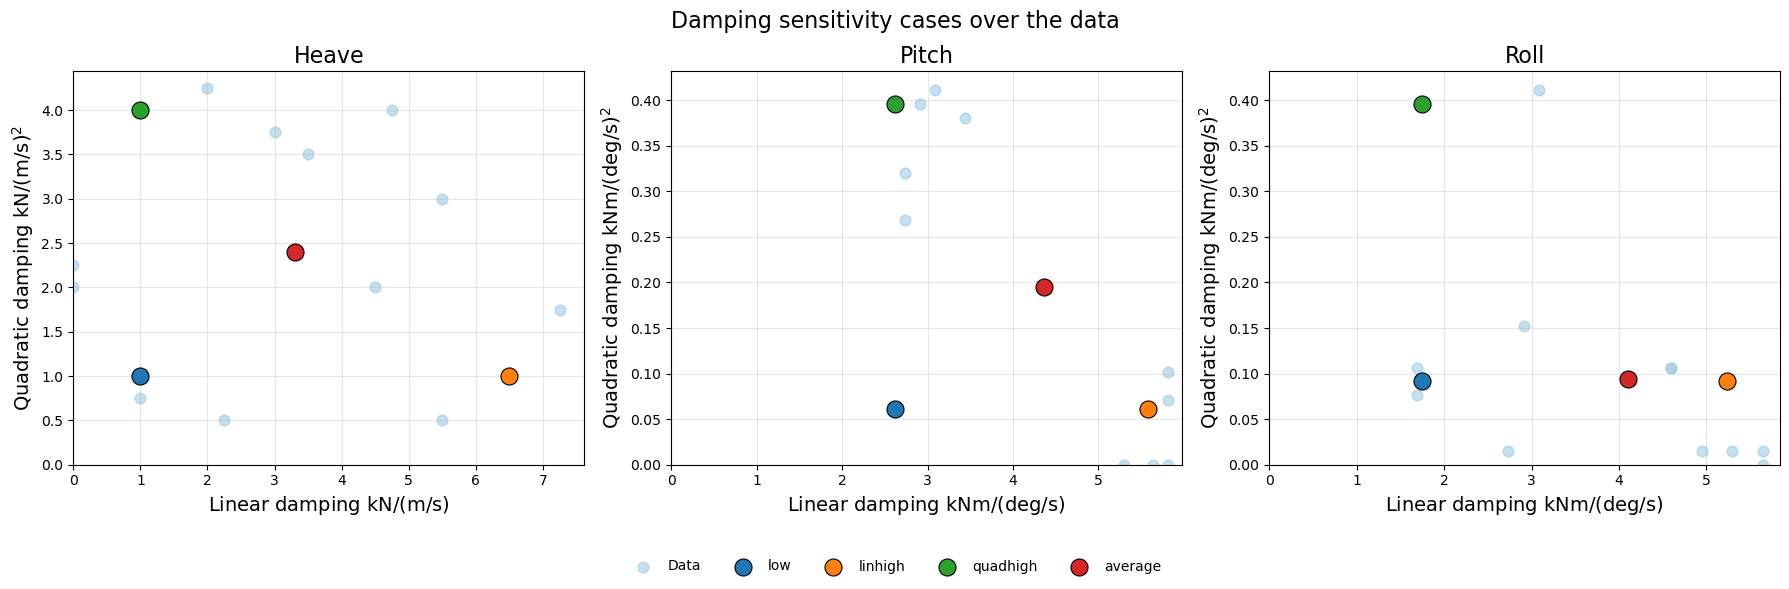

Plot opgeslagen als: C:\Users\verav\Desktop\Studie\Afstuderen\Output\Decay_calibration_outputs_V2\damping_summary_all_dofs\damping_ranges_per_dof.png


In [11]:
# =========================
# PLOT 3: sensitiviteits-cases (ranges) over de data
#   data  = licht gekleurd op de achtergrond
#   cases = low / linhigh / quadhigh / average op de hoeken + gemiddelde
# Waarden hieronder in de NATUURLIJKE eenheid (heave: m/s, pitch/roll: per rad);
# de conversie naar graden gebeurt automatisch via to_unit().
# =========================
output_path = output_dir / "damping_ranges_per_dof.png"

cases = {
    "heave": {"low": (1.0, 1.0),  "linhigh": (6.5, 1.0),  "quadhigh": (1.0, 4.0),   "average": (3.3, 2.4)},
    "pitch": {"low": (150, 200),  "linhigh": (320, 200),  "quadhigh": (150, 1300),  "average": (250, 640)},
    "roll":  {"low": (100, 300),  "linhigh": (300, 300),  "quadhigh": (100, 1300),  "average": (235, 310)},
}

case_color = {
    "low":      "#1f77b4",   # blauw
    "linhigh":  "#ff7f0e",   # oranje
    "quadhigh": "#2ca02c",   # groen
    "average":  "#d62728",   # rood
}

data_color = "#9ecae1"       # licht (data op de achtergrond)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=False, sharey=False)

for ax, dof in zip(axes, dofs):
    di = ind[ind["dof"] == dof]

    # data licht op de achtergrond
    x, y = to_unit(dof, di["linear_damping"], di["quadratic_damping"])
    ax.scatter(x, y, marker="o", s=60, color=data_color, alpha=0.6,
               label="Data", zorder=1)

    # cases er bovenop
    for case, (lin, quad) in cases[dof].items():
        cx, cy = to_unit(dof, lin, quad)
        ax.scatter(cx, cy, marker="o", s=150, color=case_color[case],
                   edgecolor="black", linewidth=0.8, label=case, zorder=3)

    lin_unit, quad_unit = damping_units(dof)
    ax.set_title(dof.capitalize(), fontsize=TITLE_SIZE)
    ax.set_xlabel(f"Linear damping {lin_unit}", fontsize=LABEL_SIZE)
    ax.set_ylabel(f"Quadratic damping {quad_unit}", fontsize=LABEL_SIZE)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)

handles, labels = [], []
for ax in axes:
    h, l = ax.get_legend_handles_labels()
    handles.extend(h); labels.extend(l)
unique = dict(zip(labels, handles))
fig.legend(unique.values(), unique.keys(), loc="lower center", ncol=5,
           frameon=False, bbox_to_anchor=(0.5, -0.03))

fig.suptitle("Damping sensitivity cases over the data", fontsize=16, y=0.93)
fig.tight_layout(rect=[0, 0.06, 1, 0.96])
fig.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Plot opgeslagen als: {output_path}")
